# Garbage Classification — Phase 2: Data Pipeline and MLP Baselines

**Team:** Moaz Ahmed (202351710), Abdulaziz Mahmoud (202279480)
**Dataset:** [Garbage Classification (12 classes), Kaggle](https://www.kaggle.com/datasets/mostafaabla/garbage-classification)
**Task:** single-label, 12-class image classification (input: RGB photo of one waste item, output: its category).

This notebook builds a complete PyTorch data pipeline and trains two multilayer perceptrons (MLPs):
a **shallow MLP (2 hidden layers)** and a **deep MLP (5 hidden layers)**.
Every step is written as a reusable function or class so it can be imported into later phases.

**Selection metric.** As stated in our Phase 1 proposal, every model choice is made with the
**validation macro-averaged F1 score**, because the classes are imbalanced (clothes is 34% of the data,
brown glass 4%). Accuracy is reported next to it. The test set is used **only once**, in Section 3.7.

---
# Part 0 — Setup

### 0.1 Install and import libraries
PyTorch, scikit-learn, pandas and matplotlib are already installed in Google Colab; only `kagglehub` may be missing.

In [1]:
%pip install -q kagglehub

In [2]:
import copy
import random
import time
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from PIL import Image
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

### 0.2 Configuration
All settings live in one cell so they are easy to find and change.

In [3]:
# ---------------- Data ----------------
DATASET_HANDLE = 'mostafaabla/garbage-classification'
CLASS_NAMES = [
    'battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass',
    'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass',
]
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
IMAGE_SIZE = 64         # every image is resized to 64 x 64 pixels -> 64 * 64 * 3 = 12,288 inputs
TEST_FRACTION = 0.20    # 80% train+validation / 20% test
VAL_FRACTION = 0.20     # the 80% part is split again: 80% train / 20% validation
BATCH_SIZE = 128
SEED = 42

# ---------------- Models ----------------
SHALLOW_HIDDEN = [512, 256]               # 2 hidden layers
DEEP_HIDDEN = [512, 256, 128, 64, 32]     # 5 hidden layers
DROPOUT = 0.3

# ---------------- Training ----------------
EPOCHS = 40
WEIGHT_DECAY = 1e-4     # L2 regularisation strength (lambda), used by every optimizer
LABEL_SMOOTHING = 0.1   # used by the "CE + Label Smoothing" loss
FOCAL_GAMMA = 2.0       # focusing parameter of the focal loss

LOSS_NAMES = ['Cross-Entropy', 'CE + Label Smoothing', 'Focal Loss']
OPTIMIZER_NAMES = ['SGD + Momentum', 'RMSprop', 'Adam']

# Learning rate used for each optimizer in the 3 x 3 comparison (a standard starting value for each).
DEFAULT_LR = {
    'SGD + Momentum': 1e-2,
    'RMSprop': 1e-3,
    'Adam': 1e-3,
}

# Four learning rates tried in Section 3.5 for whichever optimizer wins the 3 x 3 comparison.
LR_CANDIDATES = {
    'SGD + Momentum': [1e-1, 3e-2, 1e-2, 1e-3],
    'RMSprop': [3e-3, 1e-3, 3e-4, 1e-4],
    'Adam': [3e-3, 1e-3, 3e-4, 1e-4],
}

# ---------------- Plot colours ----------------
TRAIN_COLOR = '#2a78d6'   # blue
VAL_COLOR = '#eb6834'     # orange

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


### 0.3 Reproducibility
`set_seed` is called before **every** training run, so all runs start from the same random
weights and see the training batches in the same order. This makes the comparisons fair.

In [4]:
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed()

---
# Part 1 — Data Pipeline

The pipeline is split into small functions (Steps A–D) and one method that runs them all (Step E).

**Order of the steps.** We split the data **before** computing any preprocessing statistics.
If the normalisation mean and standard deviation were computed on all images, information from
the validation and test images would leak into training (Requirement 1.7).

```
Step A  find image files + labels, show one sample per class
Step B  stratified split of the file list  -> train 64% | validation 16% | test 20%
Step C  load & resize pixels, encode labels, fit mean/std on TRAIN only, normalise, flatten, to tensors
Step D  wrap the tensors in DataLoaders
Step E  build_data_pipeline() runs A -> D
```

**Split used in this phase.** Our Phase 1 proposal planned 70/15/15. This milestone requires an
80/20 train/test split followed by an 80/20 train/validation split, so we follow the milestone:
**64% train, 16% validation, 20% test**. The dataset has no predefined split.

## Step A — Load the dataset and display one sample per class (Requirement 1.1)

The images are stored in one folder per class, so the folder name is the label.
We first collect a table of `(file path, label)` pairs; the pixels are loaded later, in Step C.

In [5]:
def download_dataset(handle=DATASET_HANDLE):
    # Download the dataset from Kaggle (or reuse the cached copy) and return its folder.
    dataset_path = Path(kagglehub.dataset_download(handle))
    print(f'Dataset folder: {dataset_path}')
    return dataset_path


def find_class_root(dataset_path, class_names=CLASS_NAMES):
    # Return the folder whose sub-folders are the 12 class folders.
    candidates = [dataset_path] + sorted(p for p in dataset_path.rglob('*') if p.is_dir())
    for folder in candidates:
        subfolder_names = {child.name for child in folder.iterdir() if child.is_dir()}
        if set(class_names).issubset(subfolder_names):
            return folder
    raise FileNotFoundError(f'Could not find the class folders inside {dataset_path}')


def load_dataset_index(class_root, class_names=CLASS_NAMES):
    # Build a table with one row per image: its file path and its label (the folder name).
    rows = []
    for class_name in class_names:
        class_folder = class_root / class_name
        for file_path in sorted(class_folder.rglob('*')):
            if file_path.is_file() and file_path.suffix.lower() in IMAGE_EXTENSIONS:
                rows.append({'path': str(file_path), 'label': class_name})
    return pd.DataFrame(rows)


def show_one_sample_per_class(index_df, class_names=CLASS_NAMES, seed=SEED):
    # Plot one randomly chosen (but reproducible) image from every class in a 3 x 4 grid.
    fig, axes = plt.subplots(3, 4, figsize=(13, 10))
    for axis, class_name in zip(axes.flat, class_names):
        class_rows = index_df[index_df['label'] == class_name]
        sample_row = class_rows.sample(n=1, random_state=seed).iloc[0]
        with Image.open(sample_row['path']) as image:
            axis.imshow(image.convert('RGB'))
        axis.set_title(f'{class_name}  ({len(class_rows):,} images)')
        axis.axis('off')
    fig.suptitle('One sample from each of the 12 classes', fontsize=15)
    plt.tight_layout()
    plt.show()

## Step B — Stratified train / validation / test split (Requirements 1.3, 1.4, 1.5)

1. **Requirement 1.3:** split all images into **80% train+validation** and **20% test**.
2. **Requirement 1.4:** split the 80% part again into **80% train** and **20% validation**.
3. **Requirement 1.5:** both splits use `stratify=label`, so every split keeps the same class
   proportions as the full dataset. This matters here because the classes are imbalanced.

In [6]:
def split_dataset(index_df, test_fraction=TEST_FRACTION, val_fraction=VAL_FRACTION, seed=SEED):
    # Split 1 (Req 1.3 + 1.5): 80% train+validation / 20% test, stratified by label.
    train_val_df, test_df = train_test_split(
        index_df,
        test_size=test_fraction,
        stratify=index_df['label'],
        random_state=seed,
    )
    # Split 2 (Req 1.4 + 1.5): the 80% part -> 80% train / 20% validation, stratified by label.
    train_df, val_df = train_test_split(
        train_val_df,
        test_size=val_fraction,
        stratify=train_val_df['label'],
        random_state=seed,
    )
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)


def split_summary_table(train_df, val_df, test_df):
    # Number of images per class in each split, plus a TOTAL row.
    table = pd.DataFrame({
        'train': train_df['label'].value_counts(),
        'validation': val_df['label'].value_counts(),
        'test': test_df['label'].value_counts(),
    }).sort_index()
    table['total'] = table.sum(axis=1)
    table.loc['TOTAL'] = table.sum(axis=0)
    return table


def print_split_percentages(train_df, val_df, test_df):
    total = len(train_df) + len(val_df) + len(test_df)
    for split_name, split_df in [('train', train_df), ('validation', val_df), ('test', test_df)]:
        print(f'{split_name:>10}: {len(split_df):6,} images ({100 * len(split_df) / total:.1f}%)')

## Step C — Preprocessing (Requirements 1.2, 1.7)

An MLP needs every input to be a vector of the same length, so each image goes through:

| Step | What happens | Why |
|---|---|---|
| **Resize** | every image → 64 × 64 RGB | the originals range from 51 to 888 px wide (Phase 1); an MLP needs a fixed input size |
| **Scale** | pixel values 0–255 → 0–1 | puts all inputs on the same small scale |
| **Normalise** | subtract the per-channel mean, divide by the per-channel std | zero-centred inputs make gradient descent faster and more stable |
| **Reshape** | (64, 64, 3) → a flat vector of 12,288 values | an MLP takes a 1-D vector, not a 2-D image |
| **Label encoding** | class name → integer 0–11 (`LabelEncoder`) | `nn.CrossEntropyLoss` expects integer class indices |
| **To tensors** | NumPy arrays → `torch.float32` inputs and `torch.long` labels | the format PyTorch models and losses use |

**Requirement 1.7 — fitted on training data only.** The `LabelEncoder` and the per-channel
mean/std are fitted on the **training split only**, then the same fitted values are applied to the
validation and test splits.

In [7]:
def load_images(paths, image_size=IMAGE_SIZE, description='Loading images'):
    # Read every image, convert it to RGB and resize it. Returns a uint8 array (N, H, W, 3).
    images = np.zeros((len(paths), image_size, image_size, 3), dtype=np.uint8)
    for i, path in enumerate(tqdm(paths, desc=description)):
        with Image.open(path) as image:
            rgb_image = image.convert('RGB')
        resized_image = rgb_image.resize((image_size, image_size), Image.Resampling.BILINEAR)
        images[i] = np.asarray(resized_image)
    return images


def fit_label_encoder(train_labels):
    # Learn the class-name -> integer mapping from the TRAINING labels only.
    return LabelEncoder().fit(train_labels)


def fit_normalizer(train_images):
    # Per-channel (R, G, B) mean and standard deviation, computed on the TRAINING images only.
    means = []
    stds = []
    for channel in range(3):
        channel_values = train_images[..., channel].astype(np.float32) / 255.0
        means.append(channel_values.mean())
        stds.append(channel_values.std())
    return np.array(means, dtype=np.float32), np.array(stds, dtype=np.float32)


def preprocess_images(images, mean, std):
    # uint8 images (N, H, W, 3) -> normalised, flattened float32 tensor (N, H * W * 3).
    pixels = images.astype(np.float32) / 255.0      # scale to [0, 1]
    pixels = (pixels - mean) / std                  # normalise each channel with the TRAIN mean/std
    pixels = pixels.reshape(len(pixels), -1)        # flatten each image into one vector
    return torch.from_numpy(pixels)


def encode_labels(labels, label_encoder):
    # Class names -> integer tensor, using the encoder fitted on the training labels.
    return torch.from_numpy(label_encoder.transform(labels)).long()

## Step D — PyTorch DataLoaders (Requirement 1.6)

* Training loader: `shuffle=True`, so the model sees the batches in a different order every epoch.
* Validation and test loaders: `shuffle=False`, because evaluation does not depend on order.
* The preprocessed tensors fit in memory, so a simple `TensorDataset` is enough.

In [8]:
def make_dataloaders(X_train, y_train, X_val, y_val, X_test, y_test, batch_size=BATCH_SIZE):
    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader

## Step E — The complete pipeline method

`build_data_pipeline()` runs Steps A → D in order and returns everything the later parts need.
It can be reused in future phases (for example, with a larger `image_size` for a CNN).

In [9]:
def build_data_pipeline(image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, seed=SEED):
    # ---- Step A: load the file list and show one sample per class (Req 1.1) ----
    print('Step A: loading the dataset index')
    class_root = find_class_root(download_dataset())
    index_df = load_dataset_index(class_root)
    print(f'Found {len(index_df):,} images in {index_df["label"].nunique()} classes')
    show_one_sample_per_class(index_df, seed=seed)

    # ---- Step B: stratified 80/20 then 80/20 split (Req 1.3, 1.4, 1.5) ----
    print('Step B: stratified train / validation / test split')
    train_df, val_df, test_df = split_dataset(index_df, seed=seed)
    print_split_percentages(train_df, val_df, test_df)
    display(split_summary_table(train_df, val_df, test_df))

    # ---- Step C: preprocessing, fitted on the training split only (Req 1.2, 1.7) ----
    print('Step C: preprocessing')
    train_images = load_images(train_df['path'], image_size, 'Train images')
    val_images = load_images(val_df['path'], image_size, 'Validation images')
    test_images = load_images(test_df['path'], image_size, 'Test images')

    label_encoder = fit_label_encoder(train_df['label'])     # fitted on TRAIN only
    mean, std = fit_normalizer(train_images)                 # fitted on TRAIN only
    print(f'Label encoding: {dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))}')
    print(f'Training-set channel mean (R, G, B): {np.round(mean, 4)}')
    print(f'Training-set channel std  (R, G, B): {np.round(std, 4)}')

    X_train = preprocess_images(train_images, mean, std)
    X_val = preprocess_images(val_images, mean, std)
    X_test = preprocess_images(test_images, mean, std)
    y_train = encode_labels(train_df['label'], label_encoder)
    y_val = encode_labels(val_df['label'], label_encoder)
    y_test = encode_labels(test_df['label'], label_encoder)

    # ---- Step D: DataLoaders (Req 1.6) ----
    print('Step D: DataLoaders')
    train_loader, val_loader, test_loader = make_dataloaders(
        X_train, y_train, X_val, y_val, X_test, y_test, batch_size
    )

    return {
        'train_loader': train_loader,
        'val_loader': val_loader,
        'test_loader': test_loader,
        'input_dim': X_train.shape[1],
        'num_classes': len(label_encoder.classes_),
        'class_names': list(label_encoder.classes_),
        'label_encoder': label_encoder,
        'mean': mean,
        'std': std,
        'split_frames': {'train': train_df, 'validation': val_df, 'test': test_df},
    }

### Run the pipeline

Step A: loading the dataset index
Using Colab cache for faster access to the 'garbage-classification' dataset.
Dataset folder: /kaggle/input/garbage-classification
Found 15,515 images in 12 classes


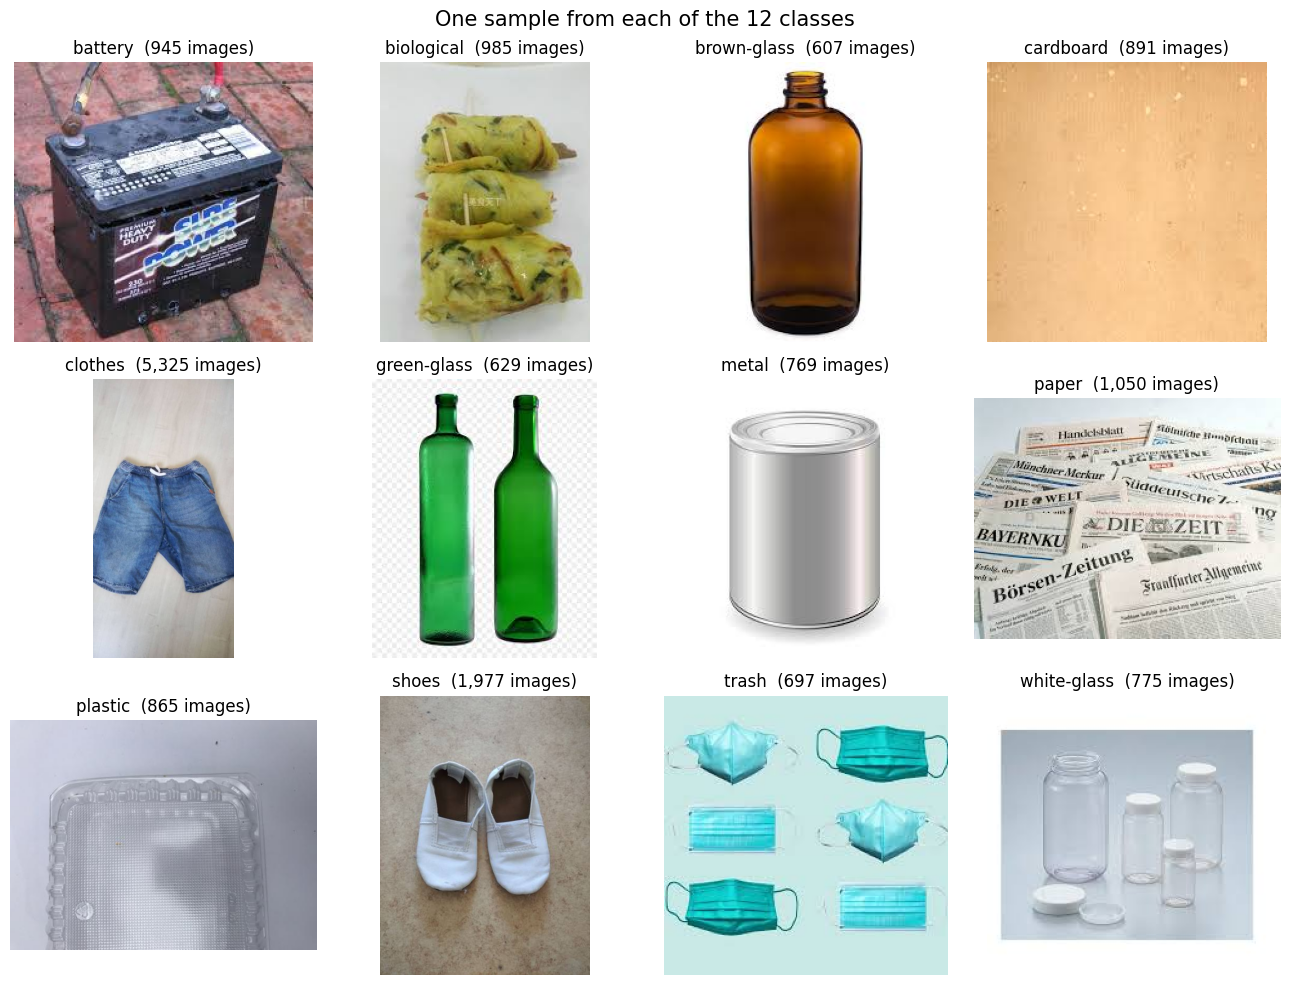

Step B: stratified train / validation / test split
     train:  9,929 images (64.0%)
validation:  2,483 images (16.0%)
      test:  3,103 images (20.0%)


,train,validation,test,total
label,,,,
battery,605,151,189,945
biological,630,158,197,985
brown-glass,388,97,122,607
cardboard,570,143,178,891
clothes,3408,852,1065,5325
green-glass,402,101,126,629
metal,492,123,154,769
paper,672,168,210,1050
plastic,554,138,173,865


Step C: preprocessing


Test images: 100%|██████████| 3103/3103 [00:17<00:00, 179.22it/s]


Label encoding: {'battery': 0, 'biological': 1, 'brown-glass': 2, 'cardboard': 3, 'clothes': 4, 'green-glass': 5, 'metal': 6, 'paper': 7, 'plastic': 8, 'shoes': 9, 'trash': 10, 'white-glass': 11}
Training-set channel mean (R, G, B): [0.6576 0.6151 0.5846]
Training-set channel std  (R, G, B): [0.2715 0.2836 0.2977]
Step D: DataLoaders


In [10]:
data = build_data_pipeline()

### Check the pipeline output
The tensors have the expected shapes and types, and the training inputs are close to mean 0 and
standard deviation 1 (they were normalised with their own statistics). The validation and test
inputs are close to, but not exactly, 0 and 1, because they were normalised with the **training**
statistics.

In [11]:
checks = []
for split_name in ['train', 'val', 'test']:
    dataset = data[f'{split_name}_loader'].dataset
    inputs, labels = dataset.tensors
    checks.append({
        'split': split_name,
        'inputs shape': tuple(inputs.shape),
        'inputs dtype': str(inputs.dtype),
        'labels dtype': str(labels.dtype),
        'input mean': round(inputs.mean().item(), 4),
        'input std': round(inputs.std().item(), 4),
        'batches per epoch': len(data[f'{split_name}_loader']),
    })
display(pd.DataFrame(checks))

batch_inputs, batch_labels = next(iter(data['train_loader']))
print(f'One training batch -> inputs {tuple(batch_inputs.shape)}, labels {tuple(batch_labels.shape)}')

,split,inputs shape,inputs dtype,labels dtype,input mean,input std,batches per epoch
0,train,"(9929, 12288)",torch.float32,torch.int64,-0.0000,1.0000,78
1,val,"(2483, 12288)",torch.float32,torch.int64,0.0128,0.9951,20
2,test,"(3103, 12288)",torch.float32,torch.int64,0.0046,0.9996,25


One training batch -> inputs (128, 12288), labels (128,)


---
# Part 2 — MLP Implementation

## 2.1 A flexible MLP class
`MLP` builds a network with **any number of hidden layers** from a list of layer sizes, so the same
class creates both networks in this notebook:

* `MLP(input_dim, [512, 256], 12)` → shallow MLP, 2 hidden layers
* `MLP(input_dim, [512, 256, 128, 64, 32], 12)` → deep MLP, 5 hidden layers

Each hidden layer is **Linear → BatchNorm → ReLU → Dropout**, and the network ends with a
**Linear output layer of 12 neurons**.

In [12]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_sizes, num_classes, dropout=DROPOUT):
        super().__init__()
        layers = []
        in_features = input_dim
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(in_features, hidden_size))
            layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            in_features = hidden_size
        # Output layer: one raw score (logit) per class. No softmax here, because
        # the loss functions below apply log-softmax themselves.
        layers.append(nn.Linear(in_features, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


def count_parameters(model):
    total = 0
    for parameter in model.parameters():
        total += parameter.numel()
    return total

## 2.2 Design choices and justification

**Number of neurons — 12,288 → 512 → 256 → 12.**
* The layers get narrower (a "funnel"): the first layer compresses 12,288 raw pixel values into
  512 features, and the second combines them into 256 higher-level features before the 12 outputs.
  Halving the width at each step is a common, simple rule of thumb.
* 512 is large enough to learn colour and texture patterns, but the first layer already has
  12,288 × 512 ≈ 6.3 M weights. Much wider layers would add millions of parameters and overfit
  quickly on about 10,000 training images.
* The deep MLP keeps the **same first two layers** and adds three more (128 → 64 → 32).
  So the only difference between the two networks is **depth**, which keeps the comparison in
  Section 3.7 fair.

**Activation function — ReLU.**
* It does not saturate for positive inputs, so gradients do not vanish as they do with
  sigmoid/tanh. This matters most for the 5-layer network.
* It is cheap to compute and is the standard default for hidden layers.

**Supporting layers.**
* **BatchNorm** keeps each layer's inputs on a stable scale, which makes training faster and less
  sensitive to the learning rate (especially for the deep MLP).
* **Dropout (p = 0.3)** randomly switches off 30% of the neurons during training, a form of
  regularisation that reduces overfitting.

**Output layer — 12 linear neurons (logits).**
* This is single-label classification with 12 classes, so there is one output per class.
* No activation is applied in the model. `nn.CrossEntropyLoss` (and our focal loss) apply
  log-softmax internally, which is more numerically stable than a softmax followed by a log.
* At prediction time, `softmax(logits)` gives class probabilities; the largest one is the predicted
  class and its confidence score (the output we defined in Phase 1).

## 2.3 Build the shallow MLP and inspect it

In [13]:
shallow_example = MLP(data['input_dim'], SHALLOW_HIDDEN, data['num_classes'])
print(shallow_example)
print(f'\nTrainable parameters: {count_parameters(shallow_example):,}')

# Quick check: one batch goes in, 12 scores per image come out.
with torch.no_grad():
    shallow_example.eval()
    example_logits = shallow_example(batch_inputs)
print(f'Input {tuple(batch_inputs.shape)} -> output {tuple(example_logits.shape)}')

MLP(
  (network): Sequential(
    (0): Linear(in_features=12288, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=12, bias=True)
  )
)

Trainable parameters: 6,427,916
Input (128, 12288) -> output (128, 12)


---
# Part 3 — Required Experiments

## 3.1 Loss functions and regularisation strength

| Loss | Formula (for the true class *y*, predicted probability *p*<sub>y</sub>) | Why it suits this task |
|---|---|---|
| **Cross-Entropy** | −log *p*<sub>y</sub> | the standard loss for multi-class classification |
| **CE + Label Smoothing** (ε = 0.1) | cross-entropy against a softened target: 0.9 + 0.1/12 for the true class, 0.1/12 for every other class | stops the model from becoming over-confident; useful because some classes look alike (the three glass colours, paper vs cardboard) |
| **Focal Loss** (γ = 2) | −(1 − *p*<sub>y</sub>)<sup>γ</sup> · log *p*<sub>y</sub> | down-weights easy examples and focuses on hard ones; designed for imbalanced data like ours |

PyTorch provides the first two (`nn.CrossEntropyLoss`). Focal loss is implemented below.

Loss values from different loss functions are not on the same scale, so the comparisons in
Sections 3.4–3.5 are made with **validation macro-F1**, not with the loss value.

In [14]:
class FocalLoss(nn.Module):
    # Multi-class focal loss: loss = -(1 - p_true) ** gamma * log(p_true)
    def __init__(self, gamma=FOCAL_GAMMA):
        super().__init__()
        self.gamma = gamma

    def forward(self, logits, targets):
        log_probs = F.log_softmax(logits, dim=1)                          # log p for every class
        log_p_true = log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)  # log p of the true class
        p_true = log_p_true.exp()
        loss = -((1 - p_true) ** self.gamma) * log_p_true
        return loss.mean()


def make_loss_fn(loss_name):
    if loss_name == 'Cross-Entropy':
        return nn.CrossEntropyLoss()
    if loss_name == 'CE + Label Smoothing':
        return nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    if loss_name == 'Focal Loss':
        return FocalLoss(gamma=FOCAL_GAMMA)
    raise ValueError(f'Unknown loss: {loss_name}')

### Selected regularisation strength

The training objective is **loss = data loss + λ · ‖w‖²**, where the L2 penalty is applied by the
optimizer through its `weight_decay` argument.

* **λ = 1 × 10⁻⁴** is used for every run. This is a common default that is strong enough to keep
  the weights small, but weak enough not to underfit, because dropout and BatchNorm already
  regularise the network.
* Keeping λ the same across all runs means the loss/optimizer comparison is not affected by
  different amounts of regularisation.

All regularisation settings used in this notebook:

In [15]:
regularisation_table = pd.DataFrame([
    {'technique': 'L2 weight decay (lambda)', 'value': WEIGHT_DECAY, 'where': 'every optimizer (weight_decay)'},
    {'technique': 'Dropout probability', 'value': DROPOUT, 'where': 'after every hidden layer'},
    {'technique': 'Label smoothing (epsilon)', 'value': LABEL_SMOOTHING, 'where': 'CE + Label Smoothing loss only'},
    {'technique': 'Best-epoch checkpoint', 'value': 'max validation macro-F1', 'where': 'every training run (a form of early stopping)'},
])
display(regularisation_table)

,technique,value,where
0,L2 weight decay (lambda),0.0001,every optimizer (weight_decay)
1,Dropout probability,0.3,after every hidden layer
2,Label smoothing (epsilon),0.1,CE + Label Smoothing loss only
3,Best-epoch checkpoint,max validation macro-F1,every training run (a form of early stopping)


## 3.2 Optimizers

| Optimizer | Settings | Learning rate in the 3 × 3 comparison |
|---|---|---|
| **SGD + Momentum** | momentum = 0.9, weight decay = 1e-4 | 0.01 |
| **RMSprop** | weight decay = 1e-4 | 0.001 |
| **Adam** | weight decay = 1e-4 | 0.001 |

Each optimizer starts from its usual default learning rate: 0.01 for SGD with momentum,
and 0.001 for the adaptive methods (RMSprop and Adam). A single shared learning rate would be unfair,
because adaptive methods take much larger effective steps than SGD. The learning rate of the winning
combination is tuned in Section 3.5.

In [16]:
def make_optimizer(optimizer_name, parameters, lr):
    if optimizer_name == 'SGD + Momentum':
        return torch.optim.SGD(parameters, lr=lr, momentum=0.9, weight_decay=WEIGHT_DECAY)
    if optimizer_name == 'RMSprop':
        return torch.optim.RMSprop(parameters, lr=lr, weight_decay=WEIGHT_DECAY)
    if optimizer_name == 'Adam':
        return torch.optim.Adam(parameters, lr=lr, weight_decay=WEIGHT_DECAY)
    raise ValueError(f'Unknown optimizer: {optimizer_name}')

## 3.3 Training and evaluation functions

| Function | Job |
|---|---|
| `compute_metrics` | loss, accuracy and macro-F1 from the collected predictions |
| `train_one_epoch` | one pass over the training data, updating the weights |
| `evaluate` | one pass over a validation/test loader **without** updating the weights |
| `train_model` | runs all epochs, records the history, and keeps the weights from the epoch with the best validation macro-F1 |
| `run_experiment` | builds a fresh model + loss + optimizer from their names, trains it, and returns a summary |
| `results_table` | turns a list of experiment results into a table |

In [17]:
def compute_metrics(total_loss, labels, predictions):
    labels = torch.cat(labels).numpy()
    predictions = torch.cat(predictions).numpy()
    return {
        'loss': total_loss / len(labels),
        'accuracy': float((predictions == labels).mean()),
        'macro_f1': f1_score(labels, predictions, average='macro'),
    }


def train_one_epoch(model, loader, loss_fn, optimizer):
    model.train()
    total_loss = 0.0
    all_labels = []
    all_predictions = []
    for inputs, labels in loader:
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        logits = model(inputs)
        loss = loss_fn(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(labels)
        all_labels.append(labels.cpu())
        all_predictions.append(logits.argmax(dim=1).cpu())
    return compute_metrics(total_loss, all_labels, all_predictions)


def evaluate(model, loader, loss_fn):
    # Returns (metrics, true labels, predicted labels).
    model.eval()
    total_loss = 0.0
    all_labels = []
    all_predictions = []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)
            logits = model(inputs)
            total_loss += loss_fn(logits, labels).item() * len(labels)
            all_labels.append(labels.cpu())
            all_predictions.append(logits.argmax(dim=1).cpu())
    metrics = compute_metrics(total_loss, all_labels, all_predictions)
    return metrics, torch.cat(all_labels).numpy(), torch.cat(all_predictions).numpy()


def train_model(model, train_loader, val_loader, loss_fn, optimizer, epochs=EPOCHS):
    history = {
        'train_loss': [], 'val_loss': [],
        'train_accuracy': [], 'val_accuracy': [],
        'train_macro_f1': [], 'val_macro_f1': [],
    }
    best_val_f1 = -1.0
    best_epoch = 0
    best_weights = None

    for epoch in range(1, epochs + 1):
        train_metrics = train_one_epoch(model, train_loader, loss_fn, optimizer)
        val_metrics, _, _ = evaluate(model, val_loader, loss_fn)

        for metric_name in ['loss', 'accuracy', 'macro_f1']:
            history[f'train_{metric_name}'].append(train_metrics[metric_name])
            history[f'val_{metric_name}'].append(val_metrics[metric_name])

        # Keep a copy of the weights from the best epoch so far (by validation macro-F1).
        if val_metrics['macro_f1'] > best_val_f1:
            best_val_f1 = val_metrics['macro_f1']
            best_epoch = epoch
            best_weights = copy.deepcopy(model.state_dict())

        if epoch == 1 or epoch % 5 == 0:
            print(
                f'  epoch {epoch:3d} | '
                f'train loss {train_metrics["loss"]:.4f}  acc {train_metrics["accuracy"]:.3f}  F1 {train_metrics["macro_f1"]:.3f} | '
                f'val loss {val_metrics["loss"]:.4f}  acc {val_metrics["accuracy"]:.3f}  F1 {val_metrics["macro_f1"]:.3f}'
            )

    model.load_state_dict(best_weights)   # restore the best epoch
    print(f'  -> best epoch {best_epoch}: validation macro-F1 = {best_val_f1:.4f}')
    return history, best_epoch


def run_experiment(data, hidden_sizes, loss_name, optimizer_name, lr, epochs=EPOCHS):
    set_seed()   # same starting weights and batch order for every run
    model = MLP(data['input_dim'], hidden_sizes, data['num_classes']).to(DEVICE)
    loss_fn = make_loss_fn(loss_name)
    optimizer = make_optimizer(optimizer_name, model.parameters(), lr)

    start_time = time.time()
    history, best_epoch = train_model(model, data['train_loader'], data['val_loader'], loss_fn, optimizer, epochs)
    training_seconds = time.time() - start_time

    best = best_epoch - 1   # list index of the best epoch
    return {
        'hidden layers': len(hidden_sizes),
        'loss': loss_name,
        'optimizer': optimizer_name,
        'learning rate': lr,
        'best epoch': best_epoch,
        'train macro-F1': history['train_macro_f1'][best],
        'val macro-F1': history['val_macro_f1'][best],
        'val accuracy': history['val_accuracy'][best],
        'train time (s)': round(training_seconds, 1),
        'model': model,
        'history': history,
    }


def results_table(results):
    # Table of the summary numbers (drops the model object and the full history).
    rows = []
    for result in results:
        row = {}
        for key, value in result.items():
            if key not in ('model', 'history'):
                row[key] = value
        rows.append(row)
    return pd.DataFrame(rows)

## 3.4 Comparison 1 — 3 × 3 loss × optimizer grid on the shallow MLP

Nine runs of the shallow MLP (2 hidden layers), one for every loss/optimizer pair.
Everything else is kept the same: architecture, seed, epochs, batch size and regularisation.

In [18]:
grid_results = []
for loss_name in LOSS_NAMES:
    for optimizer_name in OPTIMIZER_NAMES:
        lr = DEFAULT_LR[optimizer_name]
        print(f'\n=== Shallow MLP | {loss_name} | {optimizer_name} | lr = {lr} ===')
        result = run_experiment(data, SHALLOW_HIDDEN, loss_name, optimizer_name, lr)
        grid_results.append(result)


=== Shallow MLP | Cross-Entropy | SGD + Momentum | lr = 0.01 ===
  epoch   1 | train loss 1.5188  acc 0.493  F1 0.333 | val loss 1.2264  acc 0.598  F1 0.474
  epoch   5 | train loss 1.0163  acc 0.658  F1 0.552 | val loss 1.0391  acc 0.652  F1 0.539
  epoch  10 | train loss 0.8235  acc 0.721  F1 0.631 | val loss 1.0078  acc 0.664  F1 0.569
  epoch  15 | train loss 0.6852  acc 0.768  F1 0.690 | val loss 1.0223  acc 0.671  F1 0.573
  epoch  20 | train loss 0.5780  acc 0.801  F1 0.735 | val loss 1.0476  acc 0.672  F1 0.572
  epoch  25 | train loss 0.4813  acc 0.836  F1 0.779 | val loss 1.0562  acc 0.690  F1 0.595
  epoch  30 | train loss 0.4284  acc 0.852  F1 0.800 | val loss 1.1314  acc 0.679  F1 0.585
  epoch  35 | train loss 0.3830  acc 0.869  F1 0.826 | val loss 1.1513  acc 0.674  F1 0.577
  epoch  40 | train loss 0.3192  acc 0.886  F1 0.843 | val loss 1.1903  acc 0.684  F1 0.596
  -> best epoch 40: validation macro-F1 = 0.5961

=== Shallow MLP | Cross-Entropy | RMSprop | lr = 0.001 =

### Results table and best combination
Each value is taken at the run's best epoch. The combination with the **highest validation
macro-F1** is selected.

In [19]:
grid_table = results_table(grid_results)
display(grid_table.sort_values('val macro-F1', ascending=False).round(4).reset_index(drop=True))

print('Validation macro-F1 (rows = loss function, columns = optimizer):')
f1_grid = grid_table.pivot(index='loss', columns='optimizer', values='val macro-F1')
display(f1_grid.loc[LOSS_NAMES, OPTIMIZER_NAMES].round(4))

print('Validation accuracy (rows = loss function, columns = optimizer):')
accuracy_grid = grid_table.pivot(index='loss', columns='optimizer', values='val accuracy')
display(accuracy_grid.loc[LOSS_NAMES, OPTIMIZER_NAMES].round(4))

best_grid_row = grid_table.loc[grid_table['val macro-F1'].idxmax()]
BEST_LOSS = best_grid_row['loss']
BEST_OPTIMIZER = best_grid_row['optimizer']
print(f'Best combination: {BEST_LOSS} + {BEST_OPTIMIZER} '
      f'(validation macro-F1 = {best_grid_row["val macro-F1"]:.4f})')

,hidden layers,loss,optimizer,learning rate,best epoch,train macro-F1,val macro-F1,val accuracy,train time (s)
0,2,Focal Loss,SGD + Momentum,0.010,32,0.7968,0.6086,0.6931,23.4
1,2,CE + Label Smoothing,SGD + Momentum,0.010,19,0.7273,0.6050,0.6919,23.7
2,2,Cross-Entropy,Adam,0.001,40,0.7815,0.6025,0.6899,25.7
3,2,Cross-Entropy,SGD + Momentum,0.010,40,0.8434,0.5961,0.6839,22.8
4,2,Focal Loss,Adam,0.001,40,0.7602,0.5947,0.6786,26.9
5,2,Cross-Entropy,RMSprop,0.001,29,0.7430,0.5927,0.6810,24.1
6,2,CE + Label Smoothing,Adam,0.001,26,0.7284,0.5907,0.6839,27.0
7,2,CE + Label Smoothing,RMSprop,0.001,21,0.6974,0.5817,0.6714,25.4
8,2,Focal Loss,RMSprop,0.001,30,0.7145,0.5804,0.6645,25.2


Validation macro-F1 (rows = loss function, columns = optimizer):


optimizer,SGD + Momentum,RMSprop,Adam
loss,,,
Cross-Entropy,0.5961,0.5927,0.6025
CE + Label Smoothing,0.6050,0.5817,0.5907
Focal Loss,0.6086,0.5804,0.5947


Validation accuracy (rows = loss function, columns = optimizer):


optimizer,SGD + Momentum,RMSprop,Adam
loss,,,
Cross-Entropy,0.6839,0.6810,0.6899
CE + Label Smoothing,0.6919,0.6714,0.6839
Focal Loss,0.6931,0.6645,0.6786


Best combination: Focal Loss + SGD + Momentum (validation macro-F1 = 0.6086)


## 3.5 Comparison 2 — Four learning rates for the best combination

The best loss and optimizer from Section 3.4 are kept, and the shallow MLP is trained with four
learning rates (the candidate list for that optimizer is defined in the configuration cell).
The learning rate with the highest validation macro-F1 is selected.

In [20]:
lr_results = []
for lr in LR_CANDIDATES[BEST_OPTIMIZER]:
    print(f'\n=== Shallow MLP | {BEST_LOSS} | {BEST_OPTIMIZER} | lr = {lr} ===')
    result = run_experiment(data, SHALLOW_HIDDEN, BEST_LOSS, BEST_OPTIMIZER, lr)
    lr_results.append(result)


=== Shallow MLP | Focal Loss | SGD + Momentum | lr = 0.1 ===
  epoch   1 | train loss 1.2386  acc 0.453  F1 0.318 | val loss 0.9291  acc 0.548  F1 0.419
  epoch   5 | train loss 0.6746  acc 0.633  F1 0.539 | val loss 0.6816  acc 0.642  F1 0.534
  epoch  10 | train loss 0.5315  acc 0.693  F1 0.612 | val loss 0.6421  acc 0.660  F1 0.565
  epoch  15 | train loss 0.4305  acc 0.728  F1 0.655 | val loss 0.6282  acc 0.673  F1 0.581
  epoch  20 | train loss 0.3597  acc 0.766  F1 0.699 | val loss 0.6508  acc 0.676  F1 0.586
  epoch  25 | train loss 0.3025  acc 0.796  F1 0.732 | val loss 0.6682  acc 0.672  F1 0.588
  epoch  30 | train loss 0.2681  acc 0.807  F1 0.751 | val loss 0.6756  acc 0.687  F1 0.594
  epoch  35 | train loss 0.2423  acc 0.829  F1 0.780 | val loss 0.6894  acc 0.674  F1 0.585
  epoch  40 | train loss 0.2056  acc 0.852  F1 0.807 | val loss 0.6942  acc 0.683  F1 0.594
  -> best epoch 18: validation macro-F1 = 0.5986

=== Shallow MLP | Focal Loss | SGD + Momentum | lr = 0.03 ==

In [21]:
lr_table = results_table(lr_results)
display(lr_table.round(4))

best_lr_index = lr_table['val macro-F1'].idxmax()
BEST_LR = lr_table.loc[best_lr_index, 'learning rate']
best_shallow = lr_results[best_lr_index]   # the final shallow model (optimal loss, optimizer and lr)
print(f'Best learning rate: {BEST_LR} (validation macro-F1 = {lr_table.loc[best_lr_index, "val macro-F1"]:.4f})')
print(f'\nOptimal settings -> loss: {BEST_LOSS} | optimizer: {BEST_OPTIMIZER} | learning rate: {BEST_LR}')

,hidden layers,loss,optimizer,learning rate,best epoch,train macro-F1,val macro-F1,val accuracy,train time (s)
0,2,Focal Loss,SGD + Momentum,0.100,18,0.6895,0.5986,0.6855,23.4
1,2,Focal Loss,SGD + Momentum,0.030,33,0.8068,0.6064,0.6834,23.3
2,2,Focal Loss,SGD + Momentum,0.010,32,0.7968,0.6086,0.6931,23.0
3,2,Focal Loss,SGD + Momentum,0.001,25,0.7252,0.5834,0.6786,23.4


Best learning rate: 0.01 (validation macro-F1 = 0.6086)

Optimal settings -> loss: Focal Loss | optimizer: SGD + Momentum | learning rate: 0.01


## 3.6 Comparison 3 — Deep MLP (5 hidden layers) with the optimal settings

The deep MLP `[512, 256, 128, 64, 32]` is trained with the loss function, optimizer and learning
rate selected above. Everything else is the same as for the shallow MLP.

In [22]:
deep_example = MLP(data['input_dim'], DEEP_HIDDEN, data['num_classes'])
print(deep_example)
print(f'\nTrainable parameters: {count_parameters(deep_example):,}')

MLP(
  (network): Sequential(
    (0): Linear(in_features=12288, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=128, out_features=64, bias=True)
    (13): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Dropout(p=0.3, inplace=False)
    (16): Linear(in_features=64, out_features=32, bias=True)
    (17): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_runni

In [23]:
print(f'=== Deep MLP | {BEST_LOSS} | {BEST_OPTIMIZER} | lr = {BEST_LR} ===')
best_deep = run_experiment(data, DEEP_HIDDEN, BEST_LOSS, BEST_OPTIMIZER, BEST_LR)

print('\nValidation comparison (optimal settings):')
display(results_table([best_shallow, best_deep]).round(4))

=== Deep MLP | Focal Loss | SGD + Momentum | lr = 0.01 ===
  epoch   1 | train loss 1.5829  acc 0.358  F1 0.139 | val loss 1.2174  acc 0.455  F1 0.189
  epoch   5 | train loss 0.9802  acc 0.522  F1 0.356 | val loss 0.8448  acc 0.571  F1 0.420
  epoch  10 | train loss 0.8276  acc 0.568  F1 0.420 | val loss 0.7650  acc 0.594  F1 0.452
  epoch  15 | train loss 0.7444  acc 0.601  F1 0.469 | val loss 0.7617  acc 0.600  F1 0.470
  epoch  20 | train loss 0.6811  acc 0.627  F1 0.499 | val loss 0.7456  acc 0.613  F1 0.490
  epoch  25 | train loss 0.6178  acc 0.651  F1 0.530 | val loss 0.7454  acc 0.621  F1 0.505
  epoch  30 | train loss 0.5806  acc 0.662  F1 0.543 | val loss 0.7683  acc 0.621  F1 0.497
  epoch  35 | train loss 0.5428  acc 0.680  F1 0.572 | val loss 0.7644  acc 0.629  F1 0.513
  epoch  40 | train loss 0.4955  acc 0.695  F1 0.587 | val loss 0.7595  acc 0.636  F1 0.516
  -> best epoch 33: validation macro-F1 = 0.5248

Validation comparison (optimal settings):


,hidden layers,loss,optimizer,learning rate,best epoch,train macro-F1,val macro-F1,val accuracy,train time (s)
0,2,Focal Loss,SGD + Momentum,0.01,32,0.7968,0.6086,0.6931,23.0
1,5,Focal Loss,SGD + Momentum,0.01,33,0.5705,0.5248,0.6379,27.4


## 3.7 Comparison 4 — Shallow vs deep MLP on the test set

This is the **first and only time** the test set is used. Both models use the weights from their
best validation epoch.

In [24]:
final_models = {
    'Shallow MLP (2 hidden layers)': best_shallow,
    'Deep MLP (5 hidden layers)': best_deep,
}
test_loss_fn = make_loss_fn(BEST_LOSS)

test_rows = []
test_predictions = {}
for model_name, result in final_models.items():
    test_metrics, y_true, y_pred = evaluate(result['model'], data['test_loader'], test_loss_fn)
    test_predictions[model_name] = (y_true, y_pred)
    test_rows.append({
        'model': model_name,
        'parameters': count_parameters(result['model']),
        'best epoch': result['best epoch'],
        'train time (s)': result['train time (s)'],
        'val macro-F1': result['val macro-F1'],
        f'test loss ({BEST_LOSS})': test_metrics['loss'],
        'test accuracy': test_metrics['accuracy'],
        'test macro-F1': test_metrics['macro_f1'],
    })

test_table = pd.DataFrame(test_rows).set_index('model')
display(test_table.round(4))

,parameters,best epoch,train time (s),val macro-F1,test loss (Focal Loss),test accuracy,test macro-F1
model,,,,,,,
Shallow MLP (2 hidden layers),6427916,32,23.0,0.6086,0.7552,0.6848,0.5944
Deep MLP (5 hidden layers),6468908,33,27.4,0.5248,0.7601,0.6397,0.5183


### Per-class test F1
Macro-F1 is the average of these 12 values. The table shows which classes each network finds hard.

In [25]:
per_class_f1 = {}
for model_name, (y_true, y_pred) in test_predictions.items():
    per_class_f1[model_name] = f1_score(y_true, y_pred, average=None)

per_class_table = pd.DataFrame(per_class_f1, index=data['class_names'])
per_class_table['difference (deep - shallow)'] = (
    per_class_table['Deep MLP (5 hidden layers)'] - per_class_table['Shallow MLP (2 hidden layers)']
)
display(per_class_table.sort_values('Shallow MLP (2 hidden layers)').round(3))

,Shallow MLP (2 hidden layers),Deep MLP (5 hidden layers),difference (deep - shallow)
metal,0.401,0.355,-0.046
plastic,0.485,0.417,-0.068
white-glass,0.493,0.034,-0.458
biological,0.496,0.500,0.004
brown-glass,0.557,0.566,0.009
trash,0.566,0.523,-0.043
paper,0.567,0.523,-0.044
cardboard,0.599,0.534,-0.066
shoes,0.603,0.514,-0.089
battery,0.630,0.551,-0.079


### Test confusion matrices
Each row is normalised to sum to 1, so the diagonal is the recall of each class.

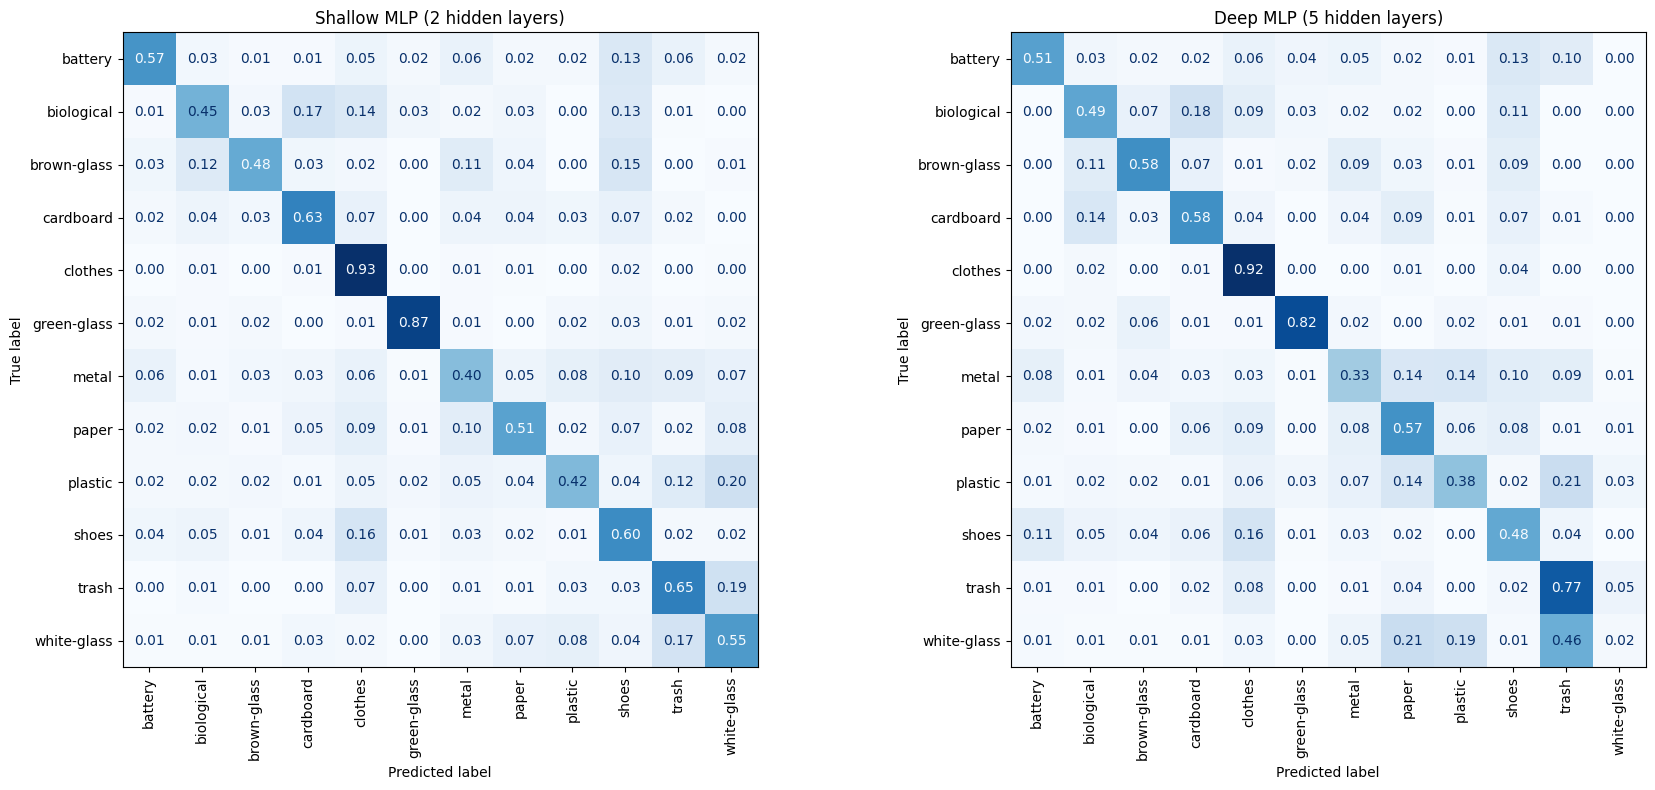

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for axis, (model_name, (y_true, y_pred)) in zip(axes, test_predictions.items()):
    matrix = confusion_matrix(y_true, y_pred, normalize='true')
    ConfusionMatrixDisplay(matrix, display_labels=data['class_names']).plot(
        ax=axis, cmap='Blues', values_format='.2f', colorbar=False
    )
    axis.set_title(model_name)
    axis.tick_params(axis='x', labelrotation=90)
plt.tight_layout()
plt.show()

---
# Part 4 — Required Plots

For both networks trained with the optimal settings:

* **left:** training and validation **loss** vs epoch
* **middle and right:** training and validation **performance** vs epoch, using accuracy and
  macro-F1

The dotted vertical line marks the best validation epoch, whose weights were kept.

In [27]:
def plot_training_curves(result, title):
    history = result['history']
    epochs = range(1, len(history['train_loss']) + 1)
    panels = [
        ('loss', 'Loss'),
        ('accuracy', 'Accuracy'),
        ('macro_f1', 'Macro-F1'),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
    for axis, (metric_name, label) in zip(axes, panels):
        axis.plot(epochs, history[f'train_{metric_name}'], color=TRAIN_COLOR, linewidth=2, label='Training')
        axis.plot(epochs, history[f'val_{metric_name}'], color=VAL_COLOR, linewidth=2, linestyle='--', label='Validation')
        axis.axvline(result['best epoch'], color='gray', linestyle=':', linewidth=1.5, label=f'Best epoch ({result["best epoch"]})')
        axis.set_title(f'{label} vs epoch')
        axis.set_xlabel('Epoch')
        axis.set_ylabel(label)
        axis.grid(alpha=0.3)
        axis.spines[['top', 'right']].set_visible(False)
        axis.legend()
    fig.suptitle(f'{title}  |  {result["loss"]} + {result["optimizer"]}, lr = {result["learning rate"]}', fontsize=14)
    plt.tight_layout()
    plt.show()

## 4.1 Shallow MLP (2 hidden layers)

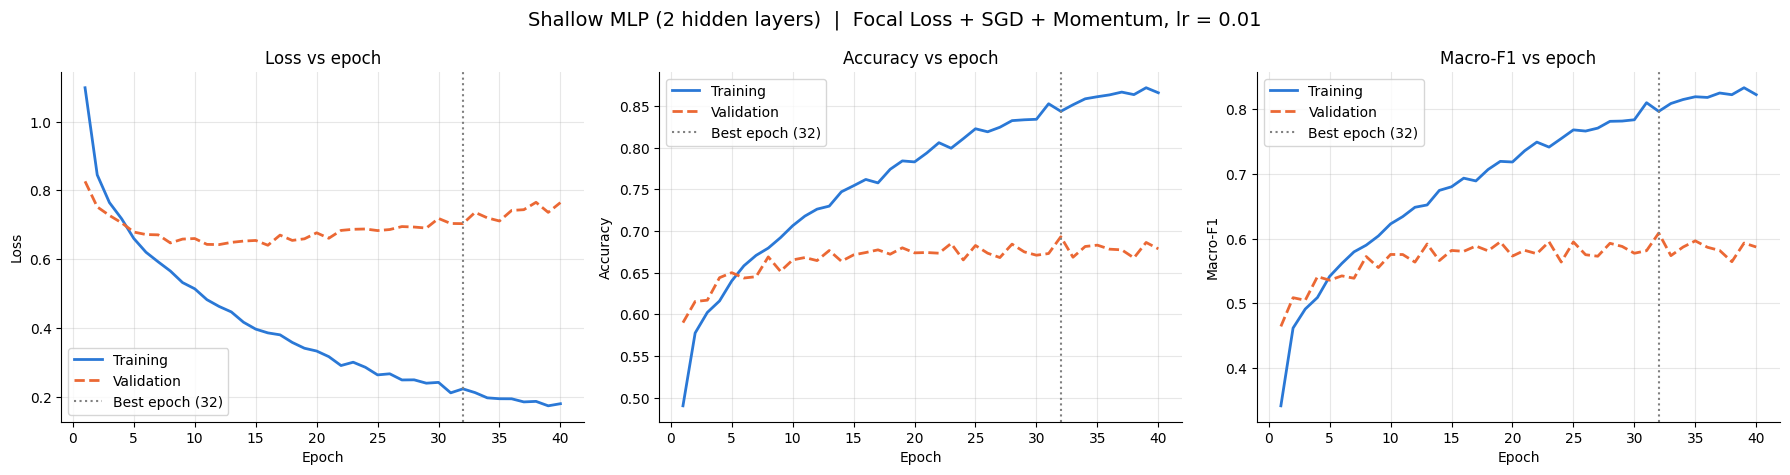

In [28]:
plot_training_curves(best_shallow, 'Shallow MLP (2 hidden layers)')

## 4.2 Deep MLP (5 hidden layers)

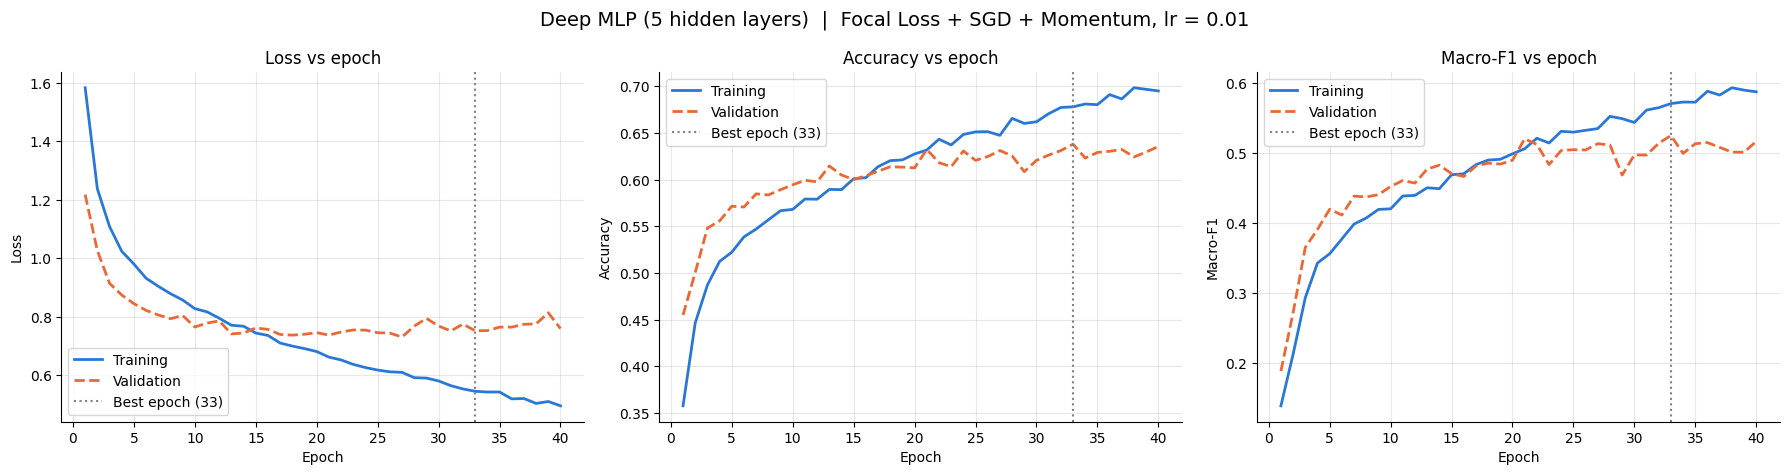

In [29]:
plot_training_curves(best_deep, 'Deep MLP (5 hidden layers)')

---
# Part 5 — Summary

In [30]:
print('Optimal settings (chosen on the validation set):')
print(f'  loss function : {BEST_LOSS}')
print(f'  optimizer     : {BEST_OPTIMIZER}')
print(f'  learning rate : {BEST_LR}')
print(f'  L2 lambda     : {WEIGHT_DECAY}')
print('\nTest-set results:')
display(test_table[['parameters', 'test accuracy', 'test macro-F1']].round(4))

Optimal settings (chosen on the validation set):
  loss function : Focal Loss
  optimizer     : SGD + Momentum
  learning rate : 0.01
  L2 lambda     : 0.0001

Test-set results:


,parameters,test accuracy,test macro-F1
model,,,
Shallow MLP (2 hidden layers),6427916,0.6848,0.5944
Deep MLP (5 hidden layers),6468908,0.6397,0.5183


## Discussion

### 1. Loss × optimizer grid (Section 3.4)
* All nine combinations reach a validation macro-F1 between **0.580 and 0.609**, so the loss and
  optimizer choices matter much less than the model type. The best combination is
  **Focal Loss + SGD with momentum (0.609)**, just ahead of CE + Label Smoothing + SGD (0.605) and
  Cross-Entropy + Adam (0.603).
* **SGD with momentum** gives the best result for two of the three losses, and **RMSprop** is the
  weakest optimizer for every loss. Its validation curves were also the noisiest (for example, the
  Focal + RMSprop run fell from 0.58 to 0.46 macro-F1 between epochs 30 and 35).
* **Focal loss** and **label smoothing** both help a little with SGD. Focal loss puts more weight on
  hard examples, which suits our imbalanced classes. The differences are about 0.01, though, and we
  used one seed per run, so the ranking between the top combinations is not very reliable.

### 2. Learning rate (Section 3.5)
* For Focal + SGD, **0.01 is best (0.609)**, with 0.03 close behind (0.606).
* **0.1 is too large**: it reaches its best score early (epoch 18, 0.599) and then stops improving.
* **0.001 is too small**: it learns more slowly and reaches only 0.583 within 40 epochs.

### 3. Shallow vs deep MLP (Sections 3.6–3.7)
| | Test accuracy | Test macro-F1 |
|---|---|---|
| Shallow MLP (2 hidden layers) | **0.685** | **0.594** |
| Deep MLP (5 hidden layers) | 0.640 | 0.518 |

* **Adding depth made the MLP worse**, even though both networks have almost the same number of
  parameters (6.43 M vs 6.47 M). The deep network **underfits**: after 40 epochs its training
  macro-F1 is only 0.59, compared with 0.82 for the shallow network, and it is still rising. Likely
  reasons are:
  * the narrow final layers (64 and 32 neurons) with 30% dropout, which remove a lot of information;
  * a learning rate that was tuned for the shallow network;
  * deeper networks usually need more epochs.
* The biggest failure is **white glass**. The deep MLP almost never predicts it (test F1 = 0.03) and
  labels most white-glass images as trash (46%) or paper (21%). The shallow MLP still has trouble
  with white glass (F1 = 0.49) but does not collapse.

### 4. Overfitting and the training curves (Part 4)
* For the **shallow MLP**, training loss keeps falling while validation loss is lowest around
  epochs 10–15 and then slowly rises. Training macro-F1 reaches 0.82 while validation stays near
  0.60. This is clear **overfitting**, even with dropout and weight decay. Keeping the weights from
  the best validation epoch (epoch 32) stops this from affecting the final model.
* The test macro-F1 of the shallow model (0.594) is close to its validation score (0.609), so the
  model selection did not overfit the validation set.

### 5. Per-class results
* **Easiest classes:** clothes (F1 0.89) and green glass (0.84). Clothes is the largest class, and
  green glass has a very distinctive colour.
* **Hardest classes:** metal (0.40), plastic (0.49), white glass (0.49) and biological (0.50). The
  confusions are between items that look alike: white glass ↔ trash ↔ plastic (transparent or white
  objects on light backgrounds), biological ↔ cardboard (brown tones), and shoes ↔ clothes.
* Test **accuracy (0.685) is clearly higher than macro-F1 (0.594)** because the large, easy clothes
  class inflates accuracy. This confirms why macro-F1 is our selection metric.

### 6. Limitations and next step
* An MLP flattens the image into 12,288 independent numbers, so it ignores where pixels are relative
  to each other and has to relearn an object at every position. It can mostly use colour and rough
  layout, which explains why colour-distinct classes are easy and shape- or material-based classes
  are hard.
* All results come from a single seed, so differences of about 0.01 macro-F1 are within run-to-run
  variation.
* **Next phase:** a convolutional neural network (CNN), which shares weights across positions and
  learns shapes and textures, should improve on this baseline, especially for metal, plastic and the
  glass classes. This notebook's data pipeline and training functions can be reused for it unchanged,
  except for the flattening step.